In [1]:
import pandas as pd
import numpy as np

In [5]:
df_hh = pd.read_spss("/data/shared/fsibilla/wfp-da4hd/DATA/in/nga/Nigeria MICS6 SPSS Datasets/Nigeria MICS6 SPSS Datasets/hh.sav")
df_hh = df_hh[['HH6','HH7','HH1','HH2','HH46','HH48','HC3','WS4']]
df_hh.head()

,HH6,HH7,HH1,HH2,HH46,HH48,HC3,WS4
0,URBAN,ABIA,1.0,1.0,COMPLETED,4.0,1.0,6.0
1,URBAN,ABIA,1.0,2.0,COMPLETED,2.0,1.0,5.0
2,URBAN,ABIA,1.0,3.0,COMPLETED,5.0,1.0,4.0
3,URBAN,ABIA,1.0,4.0,COMPLETED,4.0,45.0,15.0
4,URBAN,ABIA,1.0,5.0,COMPLETED,5.0,2.0,5.0


In [6]:
# Filter for HH46 == 'COMPLETED'
df_hh = df_hh[df_hh['HH46'] == 'COMPLETED'].copy()

# Merge HH1 and HH2 to create ID (e.g., 1.0 and 3.0 -> 13)
df_hh['ID'] = (df_hh['HH1'].astype(int).astype(str) + df_hh['HH2'].astype(int).astype(str)).astype(int)

# Rename columns
df_hh = df_hh.rename(columns={
    'HH6': 'sector',
    'HH7': 'adm1name',
    'HH48': 'hh_size',
    'HC3': 'rooms',
    'WS4': 'water_source',
    'HH1': 'psu',
    'ID':'id'
})

# Drop the original columns that are no longer needed (HH1, HH2, HH46)
df_hh = df_hh[['sector', 'adm1name', 'id', 'hh_size', 'rooms', 'water_source','psu']]
len(df_hh)

39632

In [8]:
num_cols = ['hh_size', 'rooms', 'water_source']

# forza numericità
df_hh[num_cols] = df_hh[num_cols].apply(pd.to_numeric, errors='coerce')

# colonne da NON aggregare
other_cols = [c for c in df_hh.columns if c not in num_cols + ['id']]

agg_dict = {c: 'mean' for c in num_cols}
agg_dict.update({c: 'first' for c in other_cols})

df_hh = (
    df_hh
    .sort_values('id')
    .groupby('id', as_index=False)
    .agg(agg_dict)
)
df_hh.head()

,id,hh_size,rooms,water_source,sector,adm1name,psu
0,11,4.0,1.0,6.0,URBAN,ABIA,1.0
1,12,2.0,1.0,5.0,URBAN,ABIA,1.0
2,13,5.0,1.0,4.0,URBAN,ABIA,1.0
3,14,4.0,45.0,15.0,URBAN,ABIA,1.0
4,15,5.0,2.0,5.0,URBAN,ABIA,1.0


In [9]:
len(df_hh)

37899

In [10]:
df_hh['adm1name'].nunique()

37

In [11]:
df_hl = pd.read_spss("/data/shared/fsibilla/wfp-da4hd/DATA/in/nga/Nigeria MICS6 SPSS Datasets/Nigeria MICS6 SPSS Datasets/hl.sav")
df_hl = df_hl[['HL6','HH6','HH7','HH1','HH2','ED5A','wscoreMICS','wscore']]
df_hl.head()

,HL6,HH6,HH7,HH1,HH2,ED5A,wscoreMICS,wscore
0,46.0,URBAN,ABIA,1.0,1.0,PRIMARY,0.839976,0.820389
1,22.0,URBAN,ABIA,1.0,1.0,SENIOR SECONDARY,0.839976,0.820389
2,18.0,URBAN,ABIA,1.0,1.0,SENIOR SECONDARY,0.839976,0.820389
3,10.0,URBAN,ABIA,1.0,1.0,JUNIOR SECONDARY,0.839976,0.820389
4,45.0,URBAN,ABIA,1.0,2.0,SENIOR SECONDARY,0.695187,0.700122


In [12]:
df_hl["age"] = pd.to_numeric(df_hl["HL6"], errors="coerce")
is_adult = df_hl["age"].ge(17)

In [14]:
# Map education levels to numeric values between 0 and 1 (higher education = higher value)
education_mapping = {
    # Unknown / illiterate
    "DK": 0.00,
    "NO RESPONSE": 0.00,
    None: 0.00,
    float("nan"): 0.00,

    # Pre-primary
    "ECCDE": 0.10,

    # Primary
    "PRIMARY": 0.30,

    # Lower secondary
    "JUNIOR SECONDARY": 0.45,

    # Upper secondary
    "SENIOR SECONDARY": 0.60,
    "SECONDARY TECHNICAL": 0.65,   # vocational slightly > general

    # Post-secondary non-tertiary
    "VEI/IEI": 0.75,

    # Tertiary
    "HIGHER/TERTIARY": 1.00
}
df_hl['education_numeric'] = df_hl['ED5A'].map(education_mapping).fillna(0)

# Fuse HH1 and HH2 into ID
df_hl['id'] = (df_hl['HH1'].astype(int).astype(str) + df_hl['HH2'].astype(int).astype(str)).astype(int)

# Group by ID and average education_numeric and wscore
adult_mean_edu = (
    df_hl.loc[is_adult]
         .groupby("id")["education_numeric"]
         .mean()
         .rename("avg_adult_education")
         .reset_index()
)

hh_wscore = (
    df_hl.groupby("id")["wscore"]
         .mean()
         .reset_index()
)

hh_wscoreM = (
    df_hl.groupby("id")["wscoreMICS"]
         .mean()
         .reset_index()
)

df_scores = hh_wscore.merge(hh_wscoreM, on="id", how="inner")
df_household = df_scores.merge(adult_mean_edu, on="id", how="left")

len(df_household)

37899

In [15]:
df_household.head()

,id,wscore,wscoreMICS,avg_adult_education
0,11,0.820389,0.839976,0.500
1,12,0.700122,0.695187,0.600
2,13,1.048265,1.031051,0.800
3,14,-0.460839,-0.190450,0.500
4,15,0.983845,0.999549,0.375


In [16]:
df_final = df_hh.merge(df_household, on="id", how="inner")
df_final.head()

,id,hh_size,rooms,water_source,sector,adm1name,psu,wscore,wscoreMICS,avg_adult_education
0,11,4.0,1.0,6.0,URBAN,ABIA,1.0,0.820389,0.839976,0.500
1,12,2.0,1.0,5.0,URBAN,ABIA,1.0,0.700122,0.695187,0.600
2,13,5.0,1.0,4.0,URBAN,ABIA,1.0,1.048265,1.031051,0.800
3,14,4.0,45.0,15.0,URBAN,ABIA,1.0,-0.460839,-0.190450,0.500
4,15,5.0,2.0,5.0,URBAN,ABIA,1.0,0.983845,0.999549,0.375


In [17]:
len(df_final)

37899

In [18]:
df_final['space_per_person'] = df_final['rooms'] / df_final['hh_size']

## Merge with geovariables

In [19]:
adms = pd.read_csv('/data/shared/fsibilla/wfp-da4hd/DATA/out/nga/complete_nga.csv')
adms.columns

Index(['Unnamed: 0_x', 'hhid', 'Code_adm1', 'Name_adm1', 'geometry_adm1',
       'geometry_adm2', 'Code_adm1.1', 'Name_adm2', 'Unnamed: 0_y', 'asset1',
       'asset2', 'asset3', 'asset6', 'asset7', 'asset8', 'education2',
       'food group1', 'food group2', 'food group3', 'food group4',
       'food group5', 'food group6', 'food group7', 'food group8', 'housing1',
       'housing2', 'housing4', 'labour1', 'labour2', 'labour4', 'labour5',
       'r3q', 'rfh_avg', 'vim_avg', 'Unnamed: 0', 'va_ai', 'fol_ai', 'vb12_ai',
       'fe_ai', 'zn_ai', 'mimi_simple', 'survey_id', 'zone', 'state', 'lga',
       'sector', 'ea', 'average_edu_adults', 'household_income', 'log_income',
       'log_nf_exp', 'vim_avg_1', 'rfh_avg_1', 'r3q_1', 'entropy_1',
       'entropy_2', 'rwi_1', 'rwi_2'],
      dtype='object')

In [22]:
# --- Fix unmatched NASARAWA + FCT by adding explicit aliases, then re-merge ---

import pandas as pd
import geopandas as gpd
import re
import unicodedata

def norm_adm1(x):
    if pd.isna(x):
        return pd.NA
    x = str(x).strip().upper()
    x = "".join(c for c in unicodedata.normalize("NFKD", x) if not unicodedata.combining(c))
    x = re.sub(r"\s+", " ", x)
    x = x.replace("&", "AND").replace("-", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

# Explicit aliases between your two naming systems
ALIASES = {
    # FCT variants
    "FCT": "FCT ABUJA",
    "FEDERAL CAPITAL TERRITORY": "FCT ABUJA",
    "ABUJA": "FCT ABUJA",
    "FCT ABUJA": "FCT ABUJA",

    # Nasarawa variants (just in case)
    "NASARAWA": "NASARAWA",
    "NASARAWA STATE": "NASARAWA",
    "NASSARAWA": "NASARAWA",
}

def adm1_key(x):
    x = norm_adm1(x)
    if x is pd.NA:
        return x
    return ALIASES.get(x, x)

# ---- set these to the real column names in your 'adms' dataframe ----
ADM1_NAME_COL = "Name_adm1"  
ADM1_CODE_COL = "Code_adm1"   
GEOM_COL      = "Geometry_Adm1" 

merged_df = df_final.copy()
adms = adms.copy()

merged_df["adm1_key"] = merged_df["adm1name"].map(adm1_key)
adms["adm1_key"]      = adms[ADM1_NAME_COL].map(adm1_key)

# If adms has multiple rows per ADM1 (e.g., ADM2 polygons), dissolve to ADM1
if isinstance(adms, gpd.GeoDataFrame) and GEOM_COL in adms.columns:
    adms_adm1 = adms.dissolve(by="adm1_key", as_index=False, aggfunc="first")
else:
    adms_adm1 = adms.drop_duplicates("adm1_key")

cols_to_attach = ["adm1_key", ADM1_NAME_COL]
if ADM1_CODE_COL in adms_adm1.columns:
    cols_to_attach.append(ADM1_CODE_COL)
if GEOM_COL in adms_adm1.columns:
    cols_to_attach.append(GEOM_COL)

out = merged_df.merge(
    adms_adm1[cols_to_attach],
    on="adm1_key",
    how="left",
    validate="m:1"
)

if GEOM_COL in out.columns:
    out = gpd.GeoDataFrame(out, geometry=GEOM_COL, crs=getattr(adms_adm1, "crs", None))

# Diagnostics
unmatched = out.loc[out[ADM1_NAME_COL].isna(), "adm1name"].unique()
print("Unmatched regions:", unmatched)
print("Matched %:", 100 * (1 - out[ADM1_NAME_COL].isna().mean()))

# (optional) keep output under the original variable name
merged_df_with_adms = out


Unmatched regions: [], Categories (37, object): ['ABIA', 'ADAMAWA', 'AKWA IBOM', 'ANAMBRA', ..., 'SOKOTO', 'TARABA', 'YOBE', 'ZAMFARA']
Matched %: 100.0


In [23]:
merged_df.columns

Index(['id', 'hh_size', 'rooms', 'water_source', 'sector', 'adm1name', 'psu',
       'wscore', 'wscoreMICS', 'avg_adult_education', 'space_per_person',
       'adm1_key'],
      dtype='object')

In [24]:
ADM1_ATTRS = [
    'entropy_1',
    'rwi_1','Name_adm1','Code_adm1','geometry_adm1'
]

if isinstance(adms, gpd.GeoDataFrame) and GEOM_COL in adms.columns:
    adms_adm1 = adms.dissolve(
        by="adm1_key",
        as_index=False,
        aggfunc={**{ADM1_NAME_COL:'first'},
                 **{c:'first' for c in ADM1_ATTRS},
                 **({GEOM_COL:'first'} if GEOM_COL in adms.columns else {})}
    )
else:
    adms_adm1 = (
        adms
        .drop_duplicates("adm1_key")
        [["adm1_key", ADM1_NAME_COL] + ADM1_ATTRS + 
         ([GEOM_COL] if GEOM_COL in adms.columns else [])]
    )


In [25]:
cols_to_attach = ["adm1_key", ADM1_NAME_COL] + ADM1_ATTRS
if GEOM_COL in adms_adm1.columns:
    cols_to_attach.append(GEOM_COL)

merged_df_with_adms = merged_df.merge(
    adms_adm1[cols_to_attach],
    on="adm1_key",
    how="left",
    validate="m:1"
)

if GEOM_COL in merged_df_with_adms.columns:
    merged_df_with_adms = gpd.GeoDataFrame(
        merged_df_with_adms, geometry=GEOM_COL, crs=getattr(adms_adm1,"crs",None)
    )


In [26]:
merged_df_with_adms.columns

Index(['id', 'hh_size', 'rooms', 'water_source', 'sector', 'adm1name', 'psu',
       'wscore', 'wscoreMICS', 'avg_adult_education', 'space_per_person',
       'adm1_key', 'Name_adm1', 'Name_adm1', 'entropy_1', 'rwi_1', 'Name_adm1',
       'Name_adm1', 'Code_adm1', 'geometry_adm1'],
      dtype='object')

In [27]:
len(merged_df_with_adms)

37899

In [28]:
# Map area strings to integers
area_mapping = {'URBAN': 2, 'RURAL': 1}
merged_df_with_adms['sector'] = merged_df_with_adms['sector'].map(area_mapping)

In [29]:
merged_df_with_adms.columns

Index(['id', 'hh_size', 'rooms', 'water_source', 'sector', 'adm1name', 'psu',
       'wscore', 'wscoreMICS', 'avg_adult_education', 'space_per_person',
       'adm1_key', 'Name_adm1', 'Name_adm1', 'entropy_1', 'rwi_1', 'Name_adm1',
       'Name_adm1', 'Code_adm1', 'geometry_adm1'],
      dtype='object')

In [31]:
merged_df_with_adms = merged_df_with_adms.rename(columns={
    'Name_adm1' :'adm1name',
    'geometry_adm1':'adm1geometry'
})

merged_df_with_adms=merged_df_with_adms[['adm1name','adm1geometry','id','sector','psu','wscore','avg_adult_education','space_per_person','rwi_1','entropy_1']]

In [38]:
merged_df_with_adms = merged_df_with_adms.loc[:, ~merged_df_with_adms.columns.duplicated(keep="last")]

## Save

In [39]:
merged_df_with_adms.to_csv('/data/shared/fsibilla/clean_code/Q1/experiments/nga_mics/full.csv', index=False)

In [40]:
merged_df_with_adms.head()

,adm1name,adm1geometry,id,sector,psu,wscore,avg_adult_education,space_per_person,rwi_1,entropy_1
0,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",11,2,1.0,0.820389,0.500,0.25,0.253542,3.541932
1,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",12,2,1.0,0.700122,0.600,0.50,0.253542,3.541932
2,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",13,2,1.0,1.048265,0.800,0.20,0.253542,3.541932
3,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",14,2,1.0,-0.460839,0.500,11.25,0.253542,3.541932
4,Abia,"POLYGON ((7.2515 5.1947, 7.2603 5.194, 7.2647 ...",15,2,1.0,0.983845,0.375,0.40,0.253542,3.541932


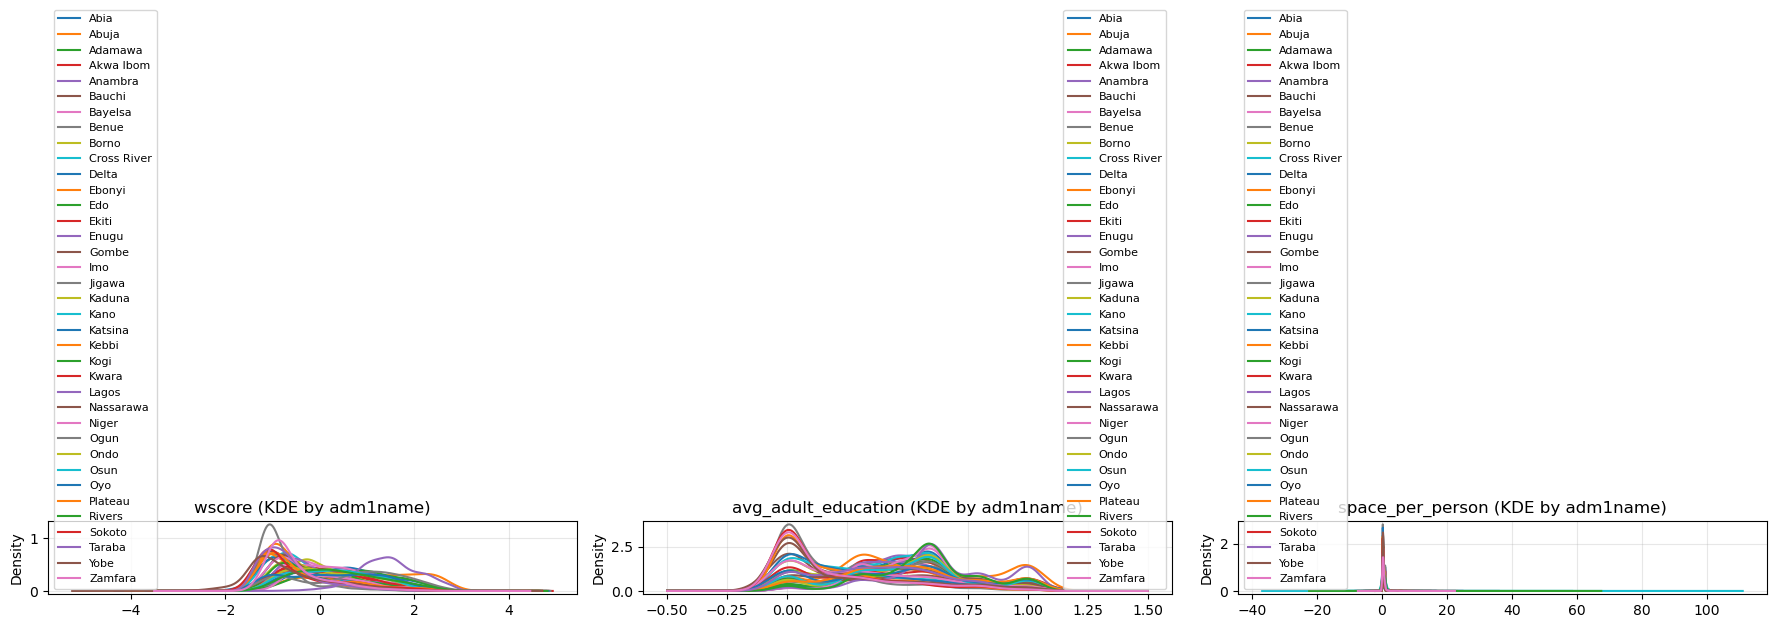

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

vars_ = ['wscore', 'avg_adult_education', 'space_per_person']
adm_col = 'adm1name'  # change to 'adm1_name' if that's the one you really want

df = merged_df_with_adms.copy()
for c in vars_:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Keep only rows with a valid adm1 label
df = df[df[adm_col].notna()].copy()

adm1_values = sorted(df[adm_col].astype(str).unique())

fig, axes = plt.subplots(1, len(vars_), figsize=(6 * len(vars_), 4), sharey=False)

for ax, col in zip(axes, vars_):
    for adm in adm1_values:
        s = df.loc[df[adm_col].astype(str) == adm, col].dropna()
        if len(s) < 5:
            continue  # too few points for a stable KDE
        s.plot(kind="kde", ax=ax, label=adm)

    ax.set_title(f"{col} (KDE by {adm_col})")
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()